
---
# RL01: Introduction to Reinforcement Learning
---

In this tutorial, we will inspect from a practical perspective the foundational algorithms of **tabular Reinforcement Learning** (RL), where the **environment** admits a **finite** number of **states** and the **agent** can choose among a **finite** set of possible **actions** in each of the states.

<center>
<img src="imgs/minecraft_interaction_loop.png" width=80% />

[*Original Image Source*](https://medium.com/student-technical-community-vit-vellore/a-brief-introduction-to-reinforcement-learning-6a74f5a61834)
</center>


The tutorial is structured as follows:
* In the **🧩 Problem Formulation** section we will learn how to represent _through code_ the elements that constitute a RL problem, i.e., the **environment** and the **policy**, and how to implement the interaction between the two.
* In the **📈 Prediction** section we will tackle the algorithms that allow to **evaluate** the **performance** of an agent in an environment and to estimate quantities of interest for the _control_ phase.
* Finally, in the **🎮 Control** section we will present the learning algorithms that allow to **optimize** the **behavior** of the agent, with the objective of learning the optimal policy for a given environment.

In this notebook you will find some **⭐ Exercise**s where you need to implement missing parts in the code. When you need to complete some code, the section is marked as:
```
# Your code goes here: -------------------------------------
# [... explanation of what you're required to implement ...]
# ----------------------------------------------------------
```

# ⚙️ Setup

Run the cell below to install and import all the notebook requirements.

_Remark._ If you're running the notebook on your machine, use `Python 3.11`. You can install all the requirements in your environment through the `requirements.txt` file.

In [1]:
import sys
if 'google.colab' in sys.modules:
    !pip install gymnasium
    !pip install numpy
    !pip install matplotlib
    !git clone https://github.com/gianmtedeschi/tutorial-rlss26.git

    %cd tutorial-rlss26/RL-basics

from utils import *
setup()

**Let's begin!**

# 🧩 Problem Formulation

## Environment

**Markov Decision Process.** The fundamental model behind a RL problem is the **Markov Decision Process** (MDP), defined by:
* A finite set of **states**: $\mathcal{S}$, $|\mathcal{S}| < +\infty$.
* A subset of **terminal states**: $\mathcal{S}^- \subseteq \mathcal{S}$.
* A finite set of **actions**: $\mathcal{A}$, $|\mathcal{A}| < +\infty$.
* A state **transition** probability **matrix**: $P(\cdot \mid s, a) \in \Delta(\mathcal{S})$.
* A **reward function**: $R(s, a)$.
* An **initial state distribution**: $\mu_0 \in \Delta(\mathcal{S})$.

_Remark._ The transition matrix and the initial state distribution are unknown: this is where learning comes into play!

**Gymnasium.** The `gymnasium` Python library models an MDP through the `Env` (_environment_) interface.

```python
class Env:
    def step(action: ActType) -> tuple[ObsType, float, bool, bool, dict]:
        ...
    
    def reset() -> tuple[ObsType, dict]:
        ...
```

The semantics of the interface is the following:
* The environment keeps track of the **current state** with an **internal attribute** `state` of type `ObsType`.
* The `step` method allows us to implement the **transition matrix** $P(\cdot \mid s, a)$ and the **reward function** $R(s, a)$. In particular, it takes as input an `action` of type `ActType` and returns a tuple containing:
    * The **next state** `next_state` of type `ObsType` and the **reward** `reward` of type `float`, generated according to the internal state `state` and the provided `action`.
    * A boolean flag `terminated` which evaluates to `True` if the `next_state` belongs to the subset of **terminal states** $\mathcal{S}^-$.
    * A boolean flag `truncated` which evaluates to `True` if the number of steps taken in the current episode reaches a **horizon** $H$. <br>_This is useful for practical reason, preventing episodes with too many time steps during training._
    * A dictionary `info` containing auxiliary diagnostic data (which we will simply return as an empty dictionary `{}`).
* The `reset` method allows us to implement the **initial state distribution** $\mu_0$. In particular, it resets the internal state of the environment and returns the new initial state `initial_state` of type `ObsType`, alongside an initial `info` dictionary (again, we simply return `{}`).

_Remark._ The `Env` interface allows modeling the more general _Partially Observable_ MDP (POMDP), where the information provided to the agent is an element of the set of _observations_ $\mathcal{O}$ which, in general, can differ from the set of states $\mathcal{S}$. The class `ObsType` represents an element of the set $\mathcal{O}$. In this notebook, we will consider just the standard MDP case, where $\mathcal{O} = \mathcal{S}$. Thus `ObsType` is the class which represents the states of the MDP.

The `gymnasium` library provides a set of ready to use environment well-known in the RL literature that can be instantiated directly through the name of the desired environment.

```python
env = gym.make('<env-name>', render_mode='<mode>')
```

**📝 Example.** The _cliff walking_ environment models a grid world in which the agent has to learn to reach a goal position from a starting state, avoiding falling off the cliff.

<center>
<div style="position: relative; width: 900px; height: 300px; overflow: hidden; border: 1px solid #ccc;">
  <img src="https://gymnasium.farama.org/_images/cliff_walking.gif" style="position: absolute; top: 0; left: 0; width: 100%; height: 100%; object-fit: cover;" />
  <img src="imgs/cliff_walking_coords.svg" style="position: absolute; top: 0; left: 0; width: 100%; height: 100%; opacity: 0.9;" />
</div>
</center>

The environment models the following MDP:
* The **state** space is the set of pairs $\mathcal{S} = \{ 0, \dots, 3 \} \times \{ 0, \dots, 11 \}$, representing the current position of the agent in the $4 \times 12$ grid.
* The **terminal states** $\mathcal{S}^- \subset \mathcal{S}$ consist of the goal state $(3, 11)$ and the cliff states $\{ (3, c) \text{ s.t. } c \in \{1, \dots, 10\} \}$. Stepping into any of these states ends the episode naturally (evaluating `terminated` to `True`).
* The agent can do one of the following **actions**: $\mathcal{A} = \{$ Up, Right, Down, Left $\}$ represented with the numbers from $0$ to $3$ in the given order.
* The **state transition** is deterministic: the agent moves in the direction given by the action, unless there is a wall (grid boundary), in which case the state won't change.
* The **reward** function is shaped to encourage the agent to reach the goal as fast as possible without falling off the cliff. The agent receives a $-1$ reward for standard steps. If it steps onto the cliff, it receives a $-100$ reward.
* The agent **starts** from a **random state** safely above the cliff.
* The **horizon** is set to $H = 50$. If the agent survives for $50$ steps of interaction without reaching a terminal state, the episode is artificially halted (evaluating `truncated` to `True`).

Below, you can find an **implementation** of the environment.

```python
UP    = 0
RIGHT = 1
DOWN  = 2
LEFT  = 3

class CliffWalkingEnv(Env):
    ROWS = 4
    COLS = 12
    CLIFF = {(3, c) for c in range(1, 11)}
    GOAL = (3, 11)

    def reset(self, *, seed=None, options=None):
        valid_states = [
            (r, c)
            for r in range(self.ROWS)
            for c in range(self.COLS)
            if (r, c) not in self.CLIFF and (r, c) != self.GOAL
        ]
        self.state = valid_states[np.random.randint(len(valid_states))]
        self.interactions = 0
        return self.state, {}

    def step(self, action: int):
        r, c = self.state
        if   action == UP    and r > 0:            self.state = (r - 1, c)
        elif action == RIGHT and c < self.COLS - 1: self.state = (r, c + 1)
        elif action == DOWN  and r < self.ROWS - 1: self.state = (r + 1, c)
        elif action == LEFT  and c > 0:             self.state = (r, c - 1)

        self.interactions += 1

        terminated = self.state == self.GOAL
        truncated  = self.interactions >= 50
        reward     = -100 if self.state in self.CLIFF else -1

        if reward == -100:
            terminated = True

        return self.state, reward, terminated, truncated, {}
```

Let's **instantiate** the cliff environment.

In [2]:
CLIFF_WALKING_ENV_NAME = 'CliffWalking-RLSS-v0'
env = gym.make(CLIFF_WALKING_ENV_NAME, render_mode='rgb_array')

## Policy

A _policy_ describes the behavior of a RL agent inside of an environment.

**Mathematical Formulation.** Given an MDP with states $\mathcal{S}$ and actions $\mathcal{A}$, a (_Markovian_) policy $\pi$ is a map $\pi : \mathcal{S} \rightarrow \Delta(\mathcal{A})$.
<br> We say that the policy is deterministic whenever $\pi(s) = \delta_{a(s)}$ for every $s \in \mathcal{S}$, where $\delta_a$ is the Dirac Delta distribution over the action $a \in \mathcal{A}$.

**Implementation.** We implement policies through the following class.

In [3]:
class Policy(ABC):
    @abstractmethod
    def get_action(self, state):
        pass

The `get_action` method samples an action from the distribution induced by $\pi$ over the set of actions $\mathcal{A}$, given `state`.

**⭐ Exercise.** Let's create a random policy for action spaces $\mathcal{A} = \{ 0, \dots, N_{\mathcal{A}} - 1 \}$ where $N_{\mathcal{A}}$ is the _number of actions_.
<br>Formally, the random policy is defined as $\pi(s) = \text{Unif}(\{ 0, \dots, N_{\mathcal{A}} - 1 \})$ for every $s \in \mathcal{S}$.

In [4]:
class RandomPolicy(Policy):
    def __init__(self, actions_cardinality):
        self.actions_cardinality = actions_cardinality
    
    def get_action(self, state):
        # Solution: ------------------------------------------------
        return np.random.randint(0, self.actions_cardinality)
        # ----------------------------------------------------------

**⭐ Exercise.** Let's create an heuristic policy to solve the _cliff walking_ environment. <br>_Hint._ You can use the constants for the action mapping `UP = 0`, `RIGHT = 1`, `DOWN = 2`, `LEFT = 3`,  which are already defined.

In [5]:
class CliffWalkingHeuristicPolicy(Policy):
    def get_action(self, state):
        # Solution: ------------------------------------------------
        if state[0] < 3 and state[1] < 11:
            return RIGHT
        elif state[0] == 3 and state[1] == 0:
            return UP
        else:
            return DOWN
        # ----------------------------------------------------------

## Interaction

**Trajectories.** Given a policy $\pi$ and an environment, a trajectory is the sequence of _current state_, _action_ taken by the agent, and corresponding observed reward:

<center>

$\tau = (S_0, A_0, R_0, \dots, S_{H-1}, A_{H-1}, R_{H-1}, S_H)$ where $R_h = R(S_h, A_h)$.

</center>

The trajectory is the mathematical object which represents the interaction of the policy with the environment.

_Remark._ When considering more than a trajectory, we use the notation $S_h(\tau)$, $A_h(\tau)$, $R_h(\tau), H(\tau)$ to differentiate the elements of the different trajectories.
We use $\tau_{h:} = (S_h, A_h, R_h, \dots, S_{H-1}, A_{H-1}, R_{H-1}, S_H)$ when considering only the portion of the trajectory which starts from time-step $h$. Observe that $S_0(\tau_{h:}) = S_h(\tau)$, etc..

**⭐ Exercise.** Given a `Policy` and an `Env`, implement the part of the `rollout` function which simulates the policy on the environment and returns a trajectory as three lists: `states`, i.e., the sequence of states of the environment $(S_0, \dots, S_{H-1})$, `actions`, i.e., the sequence of actions taken by the agent $(A_0, \dots, A_{H-1})$, and `rewards`, i.e., the sequence of rewards $(R_0, \dots, R_{H-1})$ observed by the agent.

_Remark._ When `render` is `True`, the function will return in addition the `frames` list for rendering purposes. Don't worry about this aspect, just focus on the interaction between the policy and the environment.

In [6]:
def rollout(env: gym.Env, policy: Policy, render=True):
    frames =  []

    initial_state, _ = env.reset()

    states  = [ initial_state ]
    actions = []
    rewards = []

    done = False
    while not done:
        if render:
            frames.append(env.render())
        
        # Solution -------------------------------------------------
        action = policy.get_action(states[-1])
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        actions.append(action)
        rewards.append(reward)
        states.append(next_state)
        # ----------------------------------------------------------
    
    if render:
        return frames, states, actions, rewards
    else:
        return states, actions, rewards

You can use the `animate_frames` function tot **render** the behavior of the agent. Let's try it out with the _heuristic policy_.

In [7]:
policy = CliffWalkingHeuristicPolicy()

frames, _, _, _ = rollout(env, policy)

animate_frames(frames)

## Learning Objective

**Expected Discounted Cumulative Reward.** The **goal** of a RL is to maximize the _expected discounted cumulative reward_ over the horizon $H$, for a given discount factor $\gamma \in [0, 1]$, defined as:
$$
J_\gamma^{\pi} = \mathbb{E}_{\mu_0, P, \pi} \left[\sum_{h=0}^{+\infty} \gamma^h R(S_h, A_h) \right].
$$
Given, a trajectory $\tau = (S_0, A_0, R_0, \dots, S_{H-1}, A_{H-1}, R_{H-1}, S_H)$, we can define the _expected discount cumulative reward_, in terms of the _discounted return_ of the trajectory:
$$
G_\gamma(\tau) = \sum_{h=0}^{H(\tau)-1} \gamma^h R_h(\tau).
$$
In particular, $J_\gamma^{\pi} = \mathbb{E}_{\mu_0, P, \pi} \left[ G_\gamma(\tau) \right]$.

_Remark._ We follow the convention $0^0 = 1$ when $\gamma = 0$.

**⭐ Exercise.** The `evaluate_policy` function takes in input an `Env`, a `Polcy`, a number of runs `n_runs` and the value of $\gamma$ (`discount_factor`). It simulates `n_runs` trajectories. Your task is to compute for each trajectory the corresponding discounted return. These are then averaged, obtaining an estimate of $J^\pi_\gamma$.

In [8]:
def evaluate_policy(env: gym.Env, policy: Policy, n_runs: int = 100, discount_factor: float = 1.0):
    mean_discounted_return = 0.0
    sum_squared_diffs = 0.0

    for i in tqdm(range(n_runs), desc="Evaluating Policy"):
        _, _, rewards = rollout(env, policy, render=False)
        # Solution -------------------------------------------------
        discounted_return = 0.0
        for h in range(len(rewards)):
            discounted_return += discount_factor ** h * rewards[h]
        # ----------------------------------------------------------

        # Welford's algorithm to compute running variance 
        diff_from_old_mean = discounted_return - mean_discounted_return
        mean_discounted_return += diff_from_old_mean / (i + 1)
        
        diff_from_new_mean = discounted_return - mean_discounted_return
        sum_squared_diffs += diff_from_old_mean * diff_from_new_mean

    # Compute sample standard deviation (Bessel's correction)
    if n_runs > 1:
        std_dev = (sum_squared_diffs / (n_runs - 1)) ** 0.5
    else:
        std_dev = 0.0

    # Calculate Margin of Error (95% Confidence Level, z = 1.96)
    margin_of_error = 1.96 * (std_dev / np.sqrt(n_runs)) if n_runs > 0 else 0.0
    
    lower_bound = mean_discounted_return - margin_of_error
    upper_bound = mean_discounted_return + margin_of_error

    # Compact display using formal notation
    from IPython.display import display, Markdown
    
    display(Markdown(
        f"$J^\pi_\\gamma \\in [{lower_bound:.2f}, {upper_bound:.2f}]$ w.p. $0.95$"
    ))

    return mean_discounted_return, margin_of_error

Let's **evaluate** the heuristic policy!

In [9]:
_, _ = evaluate_policy(env, policy)

Evaluating Policy: 100%|██████████| 100/100 [00:00<00:00, 6101.52it/s]


$J^\pi_\gamma \in [-7.77, -6.35]$ w.p. $0.95$

# 📈 Prediction

Given a policy $\pi$, **prediction** is concerned with the estimation of the following quantities of interest for the computation of the optimal policy in a MDP:
* The **value function** defined as:

<center>

$V_\gamma^\pi(s) = \mathbb{E}_{P,\pi}\left[ \sum_{h = 0}^{+\infty} \gamma^h R(S_h, A_h) \mid S_0 = s \right]$ for every $s \in \mathcal{S}$.

</center>

* The **$Q$ function** defined as:

<center>

$Q_\gamma^\pi(s, a) = \mathbb{E}_{P, \pi}\left[ \sum_{h = 0}^{+\infty} \gamma^h R(S_h, A_h) \mid S_0 = s, A_0 = a \right]$ for every $s \in \mathcal{S}$, $a \in \mathcal{A}$.

</center>

In particular, the value function corresponds to the expected discounted cumulative reward when the agent starts from a given state $s \in \mathcal{S}$.
The $Q$ function computes the same quantity, conditioning in addition on the first action $a \in \mathcal{A}$ taken by the agent. These functions are fundamental to understand which are the desirable states and the actions to be taken in each state. The two quantities are linked as follows:
$$
V_\gamma^\pi(s) = \sum_{a \in \mathcal{A}} \pi(a \mid s) Q_\gamma^\pi(s, a),
$$
$$
Q_\gamma^\pi(s, a) = R(s, a) + \gamma \sum_{s' \in \mathcal{S}} P(s' \mid s, a) V_\gamma^\pi(s').
$$

In what follows, we will focus **just** on the estimation of the **value function**.

**Dataset.** Prediction methods operate on a dataset of trajectories $\mathcal{T} = (\tau_i)_{i = 1}^N$. Let's generate a dataset of this kind.

_Remark._ We drop the `frames` to reduce the memory footprint.

In [10]:
NUM_TRAJECTORIES = 500

trajectories = [ rollout(env, policy, render=False) for _ in tqdm(range(NUM_TRAJECTORIES), desc="Generating Trajectories") ]

Generating Trajectories: 100%|██████████| 500/500 [00:00<00:00, 3812.07it/s]


**Monte Carlo Methods.** Monte Carlo methods rely on the _sample mean_ to estimate the expected cumulative reward. A naive approach is to simulate the policy on the environment, keep track of each trajectory which starts in the desired state $s$:
$$
\hat{V}(s) = \frac{1}{N(s)} \sum_{i = 1}^N \mathbb{I}[S_0(\tau_i) = s] G_\gamma(\tau_i),
$$
where $N(s) = \sum_{i=1}^N \mathbb{I}[S_0(\tau_i) = s]$ is the number of trajectories which start in state $s \in \mathcal{S}$.
This approach is known as _First-Visit Monte Carlo_.

It can be improved as follows: we exploit all the information inside a trajectory, by considering all the sub-trajectory at each starting time step $h$. In particular, we work on the dataset:

<center>

$\mathcal{T}^{\text{ev}} = (\tau_{i,h:}$ where $i \in \{ 1, \dots, N \}, h \in \{ 0, \dots, H(\tau_i) - 1 \} ).$

</center>

Then, we apply the same estimator of First-Visit Monte Carlo, but on this extended dataset $\mathcal{T}^{\text{ev}}$. In this way, we get a sample for each state $s \in \mathcal{S}$.
The resulting estimator, known as _Every-Visit Monte Carlo_, is:

<center>

$\hat{V}^{\text{ev}}(s) = \frac{1}{N^{\text{ev}}(s)} \sum_{i = 1}^N \sum_{h = 0}^{H(\tau_i) - 1} \mathbb{I}[S_0(\tau_{i,h:}) = s] G_\gamma(\tau_{i,h:})$,

</center>

where $N^{\text{ev}}(s) = \sum_{i=1}^N \sum_{h = 0}^{H(\tau_i) - 1} \mathbb{I}[S_0(\tau_{i,h:}) = s]$.

**⭐ Exercise.** Complete the `every_visit_monte_carlo` function by implementing the Every-Visit estimator. The function takes in input `trajectories`, i.e., the dataset $\mathcal{T}$, and the `discount_factor` $\gamma$. We assume that the environment is a grid world with `num_rows` rows and `num_cols` columns which are taken in input by the function. In this way we can store the estimates as a bidimensional `np.ndarray`.

In [11]:
def every_visit_monte_carlo(trajectories, num_rows, num_cols, discount_factor=1.0):
    returns_sum_ev = np.zeros(shape=(num_rows, num_cols))
    N_ev           = np.zeros(shape=(num_rows, num_cols))

    for trajectory in trajectories:
        states, _, rewards = trajectory

        # Solution -------------------------------------------------
        G = 0
        returns = []
        for r in reversed(rewards):
            G = r + discount_factor * G
            returns.insert(0, G)
            
        for h in range(len(rewards)): 
            returns_sum_ev[states[h]] += returns[h]
            N_ev[states[h]] += 1
        # ----------------------------------------------------------

    # Suppress errors for unvisited states    
    with np.errstate(divide='ignore', invalid='ignore'):
        V_ev = returns_sum_ev / N_ev

    return V_ev

You can use the `plot_gridworld_values` utility to **visualize** the estimated **value function**.

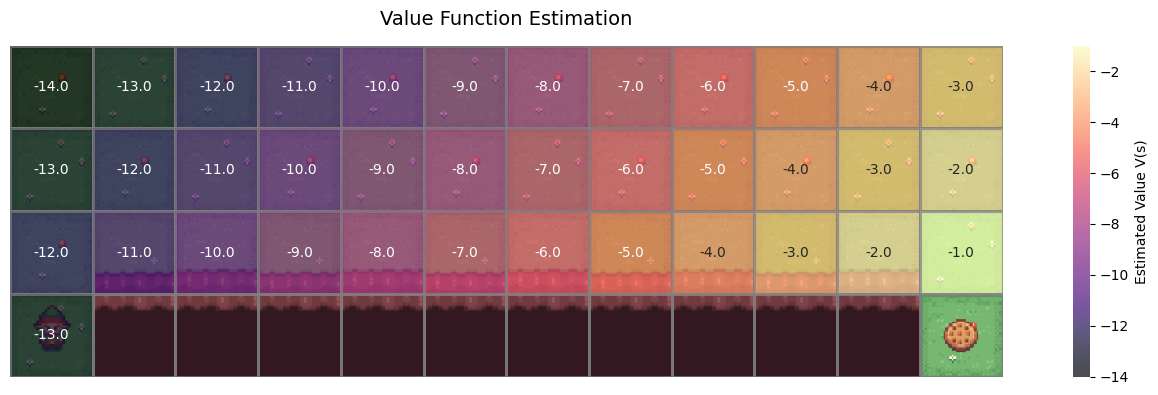

In [12]:
V_ev = every_visit_monte_carlo(
    trajectories=trajectories, 
    num_rows=4, 
    num_cols=12, 
    discount_factor=1.0
)

plot_gridworld_values(V=V_ev, gif_path='https://gymnasium.farama.org/_images/cliff_walking.gif')

**Temporal Difference Methods.**
Monte Carlo methods treat the environment largely as a black box, waiting until the end of a trajectory to calculate the actual sampled return. This ignores the underlying structure of the MDP. Temporal Difference (TD) learning, conversely, exploits the Markov property by *bootstrapping*: it updates the value of a state based on the current estimated value of the successor states.

The simplest form, **TD(0)**, relies entirely on the 1-step return:
$$G_\gamma^{(1)}(R, S', \hat{V}) = R + \gamma \hat{V}(S').$$
Observe how, because of the bootstrapping, the estimation depends on the current estimate of the value function.
In particular, the estimation of the value function is computed through an iterative approach.
* We start from the initialization $\hat{V}^{\text{td}}(s) \gets 0$ and $N(s) \gets 0$ for every $s \in \mathcal{S}$.
* For every $i \in \{ 1, \dots, N \}$, $h \in \{ 0, \dots, H(\tau_i) - 1 \}$, we do the **update**:
$$N(S_h(\tau_i)) \gets N(S_h(\tau_i)) + 1,$$
$$\hat{V}^{\text{td}}(S_h(\tau_i)) \gets \hat{V}^{\text{td}}(S_h(\tau_i)) + \alpha_{N(S_h(\tau_i))} \left(G_\gamma^{(1)}(R_h(\tau_i), S_{h+1}(\tau_i), \hat{V}^{\text{td}}) - \hat{V}^{\text{td}}(S_h(\tau_i))\right).$$

The term $\alpha_{N(s)}$ is known as the _learning rate_ for state $s$. A sufficient condition for convergence is given by the Robbins-Monro conditions: $\sum_{n=1}^{+\infty} \alpha_n = +\infty$, $\sum_{n=1}^{+\infty} \alpha_n^2 < +\infty$, e.g., $\alpha_n = 1/n$.

**⭐ Exercise.** Complete the `temporal_difference_0` function by implementing the TD(0) update with $\alpha_n = 1/n$. The function takes in input `trajectories`, i.e., the dataset $\mathcal{T}$ and the `discount_factor` $\gamma$. We assume that the environment is a grid world with `num_rows` rows and `num_cols` columns which are taken in input by the function. In this way we can store the estimates as a bidimensional `np.ndarray`.

In [13]:
def temporal_difference_0(trajectories, num_rows, num_cols, discount_factor=1.0):
    V_td = np.zeros(shape=(num_rows, num_cols))
    N    = np.zeros(shape=(num_rows, num_cols))

    for trajectory in trajectories:
        # Solution -------------------------------------------------
        states, _, rewards = trajectory
        
        for h in range(len(rewards)):
            state = states[h]
            next_state = states[h+1]
            reward = rewards[h]
            td_target = reward + discount_factor * V_td[next_state]
            td_error = td_target - V_td[state]
            N[state] += 1
            V_td[state] += 1/N[state] * td_error
        # ----------------------------------------------------------
            
    return V_td

Let's **visualize** the estimated **value function**.

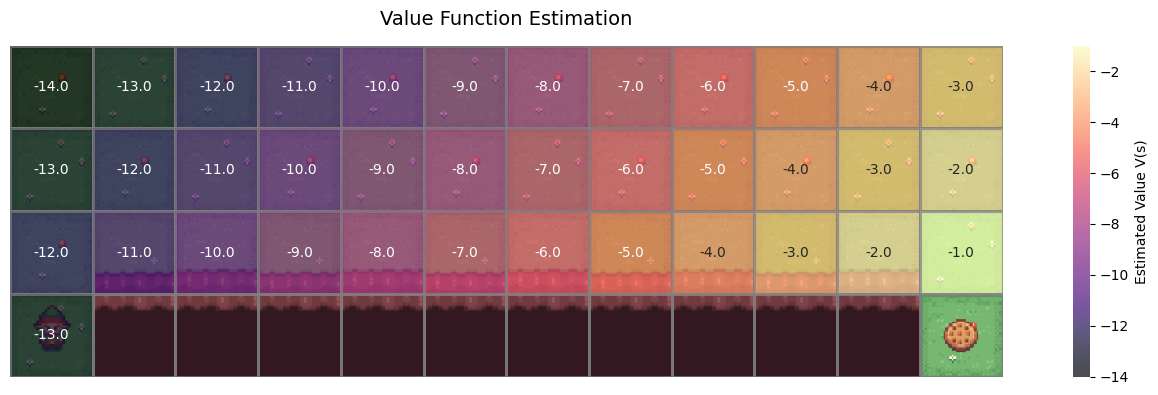

In [14]:
V_td = temporal_difference_0(
    trajectories=trajectories,
    num_rows=4,
    num_cols=12,
    discount_factor=1.0
)

plot_gridworld_values(V=V_ev, gif_path='https://gymnasium.farama.org/_images/cliff_walking.gif')

# 🎮 Control

**Bellman Optimality Equation.** _Control_ is concerned with _learning the optimal policy_, i.e., $\pi^* \in \arg\max_{\pi}{J_\gamma^{\pi}}$, by interacting with the environment. From the theory of MDPs, we know that a policy is optimal, if and only if it satisfies the so-called _Bellman Optimality Equation_:

<center>

$V^{\pi^*}(s) = \max_{a \in \mathcal{A}} Q^{\pi^*}(s, a)$ for every $s \in \mathcal{S}$.

</center>

For this reason, given the optimal $Q$ function: $Q^* = Q^{\pi^*}$ for some optimal policy $\pi$, we have that the _greedy_ policy $\pi^{\text{g}}_{Q^*} = \delta_{a^{\text{g}}_{Q^*}(s)}$ with $a^{\text{g}}_{Q^*}(s) \in \arg\max_{a \in \mathcal{A}} Q^*(s, a)$ is optimal.
The approaches that we tackle in this section are concerned with the estimation of $Q^*$, obtaining a policy which converges to the optimal one by computing the greedy policy w.r.t. the current estimate $\hat{Q}^*$.

**$\epsilon$-Greedy Policies.** The greedy policy is optimal once our estimate of the optimal $Q$ function has converged: $\hat{Q}^* \rightarrow Q^*$, but it has a critical issue: being deterministic, it doesn't allow to learn the transition matrix properly and thus to do a correct estimation of the $Q$ function.

This problem is solved by introducing the so-called $\epsilon$-greedy policies $\pi^{\text{g}}_{\hat{Q}^*, \epsilon}$, which are greedy w.p. $1 - \epsilon$ and random w.p. $\epsilon$:
$$
\mathbb{P}_{A \sim \pi^{\text{g}}_{\hat{Q}^*, \epsilon}(s)}[A = a] = \begin{cases}
    1-\epsilon+\frac{\epsilon}{|\mathcal{A}|} & \text{ if } a = a^{\text{g}}_{\hat{Q}^*}(s) \\
    \frac{\epsilon}{|\mathcal{A}|} & \text{otherwise}
\end{cases}.
$$

During learning, the value of $\epsilon$ is reduced towards $0$, e.g.:
$$
\epsilon_t = \frac{c}{t}
$$
where $c > 0$ is a constant and $t$ typically represents the episode index or global time step. Alternatively, an exponential decay is often used in empirical settings:
$$
\epsilon_t = \max(\epsilon_{\text{min}}, \epsilon_0 \exp(-\lambda t))
$$
with initial value $\epsilon_0 = 1.0$, a decay rate $\lambda > 0$, and a minimum exploration floor $\epsilon_{\text{min}}$.
<br> Let's define a scheduler for epsilon:

In [15]:
def epsilon(t, epsilon_0=1.0, epsilon_min=1e-2, lambd=1e-3):
    return max(epsilon_min, epsilon_0 * np.exp(-lambd * t))

In rigorous tabular settings, a polynomial schedule like $\epsilon_t \propto 1/t$ is particularly relevant because it satisfies the conditions for being **Greedy in the Limit with Infinite Exploration (GLIE)**. A GLIE schedule guarantees two crucial properties:
1. All state-action pairs are explored infinitely often ($\lim_{t \to \infty} N_t(s,a) = \infty$).
2. The policy asymptotically converges to a purely greedy policy ($\lim_{t \to \infty} \epsilon_t = 0$).

**⭐ Exercise.** Complete the code of the `EpsilonGreedyPolicy` class which has an internal attribute `Q` which corresponds to the (estimated) $Q$ function, and one internal attribute `epsilon` ($\epsilon$). We assuem that the environment is a grid world with `num_rows` rows and `num_columns` columns which are taken in input by the `__init__` method.
The actions, instead are $\mathcal{A} = \{ 0, \dots, N_{\mathcal{A}} - 1 \}$, where the cardinlaity of the actions set $N_{\mathcal{A}}$ is taken in input by the `__init__` method as `actions_cardinality`.

In [16]:
class EpsilonGreedyPolicy(Policy):
    def __init__(self, num_rows, num_cols, epsilon, actions_cardinality):
        self.Q_hat = np.zeros(shape=(num_rows, num_cols, actions_cardinality))
        self.epsilon = epsilon
        self.actions_cardinality = actions_cardinality
    
    def get_action(self, state):
        # Solution -------------------------------------------------
        if np.random.random() < self.epsilon:
            return np.random.randint(0, self.actions_cardinality)
        else:
            return np.argmax(self.Q_hat[state])
        # ----------------------------------------------------------

**SARSA.** _SARSA_ stands for State, Action, Reward, next State, next Action. It is an _on-policy_ control algorithm, in the sense that it estimates the optimal $Q$ function by choosing actions according to the current $\epsilon$-greedy policy $\pi^{\text{g}}_{\hat{Q}^*_t, \epsilon_t}$, which is being improved.
<br> The algorithm works as follows.
<br> **Initialize** $\hat{Q}^*(s, a) \gets 0$, $N(s, a) \gets 0$, for every $s \in \mathcal{S}, a \in \mathcal{A}$ and $t \gets 1$
<br> **For every episode**:
<br> **Sample** $S \sim \mu_0$
<br> **Sample** $A \sim \pi^{\text{g}}_{\hat{Q}^*, \epsilon_t}(S)$
<br> **Repeat until end of the episode**:
1. **Increment** $t \gets t + 1$ 
2. **Take action** $A$ and observe reward $R$ and next-state $S'$
3. **Sample** $A' \sim \pi^{\text{g}}_{\hat{Q}^*, \epsilon_t}(S')$
4. **Increment** $N(S, A) \gets N(S, A) + 1$
5. **Update** $\hat{Q}^*(S, A) \gets \hat{Q}^*(S, A) + \alpha_{N(S, A)} (R + \gamma \hat{Q}^*(S', A') - \hat{Q}^*(S, A))$
6. **Update** $S \gets S'$, $A \gets A'$

_Remark._ We chose $\alpha_n$ which satisfies the Robbins-Monro conditions.

**⭐ Exercise.** Complete the implementation of SARSA for grid worlds with `num_rows` rows, `num_cols` columns and action space $\mathcal{A} = \{ 0, \dots, N_{\mathcal{A}} - 1 \}$, where $N_{\mathcal{A}}$ is provided as `actions_cardinality`. The function takes in input `n_episodes` which is the number of episodes used for training.
The `eval_every` attribute is the number of episodes after which we run an evaluation of the current policy: this behavior is already implemented.
Use the learning rate $\alpha_n = 0.1 \frac{c}{c+n}$ where $c$ is taken in input by the algorihtm as `c`.

_Hint._ Remember to update $\epsilon_t$ and $\hat{Q}^*$ in the $\epsilon$-greedy policy. You can do so by accessing directly the attributes.

In [17]:
def SARSA(env, num_rows, num_cols, actions_cardinality, discount_factor=1.0, c=200., n_episodes=5000, eval_every=20):
    t = 1
    policy = EpsilonGreedyPolicy(num_rows, num_cols, epsilon(t), actions_cardinality)
    N = np.zeros(shape=(num_rows, num_cols, actions_cardinality))
    
    mean_returns = []
    margins_of_error = []
    evaluation_count = 0
    
    for episode in range(n_episodes):
        state, _ = env.reset()
        action = policy.get_action(state) 
        done = False

        while not done:
            # Solution -------------------------------------------------
            t = t + 1
            policy.epsilon = epsilon(t)
            
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            next_action = policy.get_action(next_state)
            
            N[(*state, action)] += 1
            
            td_target = reward + discount_factor * policy.Q_hat[(*next_state, next_action)]
            td_error = td_target - policy.Q_hat[(*state, action)]
            
            policy.Q_hat[(*state, action)] += 0.1 * c / (c + N[(*state, action)]) * td_error
            
            state = next_state
            action = next_action
            # ----------------------------------------------------------

        if (episode + 1) % eval_every == 0:
            mean_return, margin = evaluate_policy(env, policy, discount_factor=discount_factor)
            mean_returns.append(mean_return)
            margins_of_error.append(margin)

            evaluation_count += 1
            if evaluation_count % 20 == 0:
                clear_output(wait=True)

    return policy, mean_returns, margins_of_error

Let's **try** the SARSA algorithm on the _cliff walking_ environment. The `plot_training_results` function allows to visualize the evolution of the performance of the policy during the training.

Evaluating Policy: 100%|██████████| 100/100 [00:00<00:00, 3409.59it/s]


$J^\pi_\gamma \in [-9.30, -7.10]$ w.p. $0.95$

Evaluating Policy: 100%|██████████| 100/100 [00:00<00:00, 2909.07it/s]


$J^\pi_\gamma \in [-10.87, -7.25]$ w.p. $0.95$

Evaluating Policy: 100%|██████████| 100/100 [00:00<00:00, 3222.08it/s]


...

$J^\pi_\gamma \in [-10.61, -6.63]$ w.p. $0.95$

Evaluating Policy: 100%|██████████| 100/100 [00:00<00:00, 5054.60it/s]


$J^\pi_\gamma \in [-9.31, -7.69]$ w.p. $0.95$

Evaluating Policy: 100%|██████████| 100/100 [00:00<00:00, 5285.76it/s]


$J^\pi_\gamma \in [-9.84, -5.86]$ w.p. $0.95$

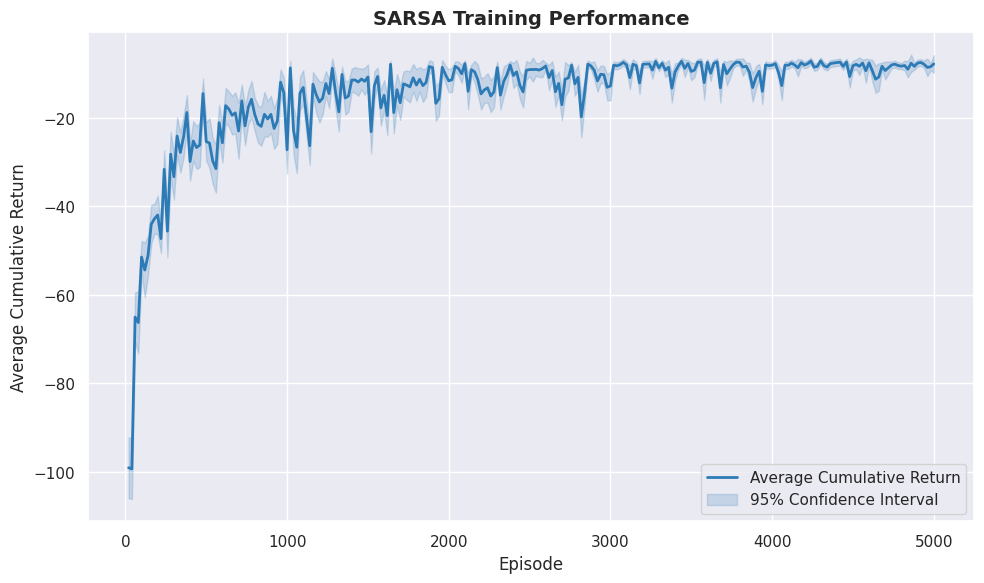

In [18]:
policy, mean_returns, margins_of_error = SARSA(env, 4, 12, 4)

plot_training_results(alg_name='SARSA', mean_returns=mean_returns, confidence_intervals=margins_of_error)

Let's visualize the behavior of the agent with the greedy policy.

In [19]:
policy.epsilon = 0.0
frames, _, _, _ = rollout(env, policy)

animate_frames(frames)

**$Q$-Learning.** The $Q$-Learning algorithm is an **off-policy** Temporal Difference (TD) control method. It directly estimates the optimal action-value function $Q^*$, regardless of the exploratory policy being followed by the agent. In particular, the sampled action is obtained from a behavioral policy that needs not be the one that we are improving. For example, we can consider an $\epsilon$-greedy policy where $\epsilon$ is fixed and still reach convergence. This is obtained thanks to a different update rule for the estimate $\hat{Q}^*$.

<br> In particular, the algorithm works as follows.
<br> **Initialize** $\hat{Q}^*(s, a) \gets 0$, $N(s, a) \gets 0$, for every $s \in \mathcal{S}, a \in \mathcal{A}$ and $t \gets 1$
<br> **For every episode**:
<br> **Sample** $S \sim \mu_0$
<br> 
<br> **Repeat until end of the episode**:
1. **Increment** $t \gets t + 1$
2. **Sample** $A \sim \pi^{\text{g}}_{\hat{Q}^*, \epsilon}(S)$
3. **Take action** $A$ and observe reward $R$ and next-state $S'$
4. **Increment** $N(S, A) \gets N(S, A) + 1$
5. **Update** $\hat{Q}^*(S, A) \gets \hat{Q}^*(S, A) + \alpha_{N(S, A)} (R + \gamma \max_{a \in \mathcal{A}} \hat{Q}^*(S, a) - \hat{Q}^*(S, A))$
6. **Update** $S \gets S'$

_Remark._ We chose $\alpha_n$ which satisfies the Robbins-Monro conditions.

**⭐ Exercise.** Complete the implementation of $Q$-learning for grid worlds with `num_rows` rows, `num_cols` columns and action space $\mathcal{A} = \{ 0, \dots, N_{\mathcal{A}} - 1 \}$, where $N_{\mathcal{A}}$ is provided as `actions_cardinality`. 

The function takes in input `n_episodes` which is the number of episodes used for training, as well as a fixed `epsilon` argument to be used by the $\epsilon$-greedy behavior policy (as remarked in the theoretical introduction). 
The `eval_every` attribute is the number of episodes after which we run an evaluation of the current policy: this behavior is already implemented.
Use the learning rate $\alpha_n = 0.1 \frac{c}{c+n}$ where $c$ is taken in input by the algorithm as `c`.

_Hint._ Remember to update $\hat{Q}^*$ in the $\epsilon$-greedy policy. You can do so by accessing the attributes directly. Keep in mind the off-policy nature of the temporal difference target. Since $\epsilon$ is fixed, you do not need to update it inside the episode loop.

In [20]:
def Q_learning(env, num_rows, num_cols, actions_cardinality, discount_factor=1.0, epsilon=0.5, c=200., n_episodes=5000, eval_every=20):
    t = 1
    policy = EpsilonGreedyPolicy(num_rows, num_cols, epsilon, actions_cardinality)
    N = np.zeros(shape=(num_rows, num_cols, actions_cardinality))
    
    mean_returns = []
    margins_of_error = []
    evaluation_count = 0
    
    for episode in range(n_episodes):
        state, _ = env.reset()
        done = False

        while not done:
            # Solution -------------------------------------------------
            t = t + 1
            action = policy.get_action(state) 
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            N[(*state, action)] += 1
            best_next_value = np.max(policy.Q_hat[(*next_state,)])
            td_target = reward + discount_factor * best_next_value
            td_error = td_target - policy.Q_hat[(*state, action)]
            policy.Q_hat[(*state, action)] += 0.1 * c / (c + N[(*state, action)]) * td_error
            state = next_state
            # ----------------------------------------------------------

        if (episode + 1) % eval_every == 0:
            policy.epsilon = 0.0
            mean_return, margin = evaluate_policy(env, policy, discount_factor=discount_factor)
            policy.epsilon = epsilon
            mean_returns.append(mean_return)
            margins_of_error.append(margin)

            evaluation_count += 1
            if evaluation_count % 20 == 0:
                clear_output(wait=True)

    return policy, mean_returns, margins_of_error

Let's **try** the $Q$-Learning algorithm on the _cliff walking_ environment.

Evaluating Policy: 100%|██████████| 100/100 [00:00<00:00, 4729.81it/s]


$J^\pi_\gamma \in [-8.73, -7.29]$ w.p. $0.95$

Evaluating Policy: 100%|██████████| 100/100 [00:00<00:00, 4639.10it/s]


$J^\pi_\gamma \in [-8.20, -6.70]$ w.p. $0.95$

Evaluating Policy: 100%|██████████| 100/100 [00:00<00:00, 3847.60it/s]


...

$J^\pi_\gamma \in [-8.53, -7.03]$ w.p. $0.95$

Evaluating Policy: 100%|██████████| 100/100 [00:00<00:00, 4396.41it/s]


$J^\pi_\gamma \in [-8.37, -6.89]$ w.p. $0.95$

Evaluating Policy: 100%|██████████| 100/100 [00:00<00:00, 5085.79it/s]


$J^\pi_\gamma \in [-7.97, -6.41]$ w.p. $0.95$

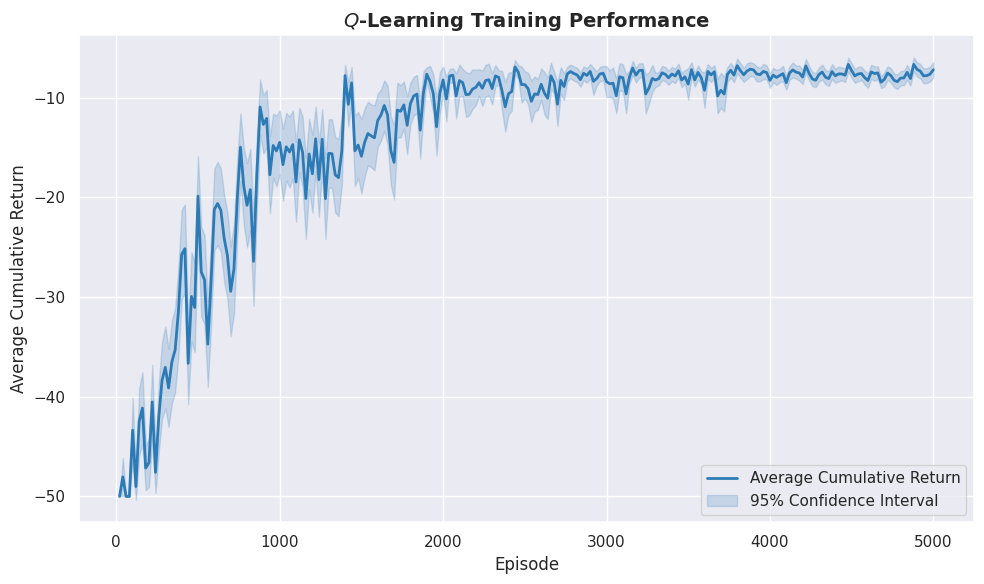

In [21]:
policy, mean_returns, margins_of_error = Q_learning(env, 4, 12, 4)

plot_training_results(alg_name='$Q$-Learning', mean_returns=mean_returns, confidence_intervals=margins_of_error)

Let's visualize the behavior of the agent with the greedy policy.

In [22]:
policy.epsilon = 0.0
frames, _, _, _ = rollout(env, policy)

animate_frames(frames)